<a href="https://colab.research.google.com/github/gordon921212/Baseball-Project/blob/main/baseball.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# install required packages
!pip install pybaseball
!pip install xgboost

In [4]:
from pybaseball import statcast

df_pitch_by_pitch = statcast(start_dt="2025-03-01", end_dt="2025-11-30")


This is a large query, it may take a moment to complete


D:\anaconda3\Lib\site-packages\pybaseball\statcast.py:50: UserWarning: 
That's a nice request you got there. It'd be a shame if something were to happen to it.
We strongly recommend that you enable caching before running this. It's as simple as `pybaseball.cache.enable()`.
Since the Statcast requests can take a *really* long time to run, if something were to happen, like: a disconnect;
gremlins; computer repair by associates of Rudy Giuliani; electromagnetic interference from metal trash cans; etc.;
you could lose a lot of progress. Enabling caching will allow you to immediately recover all the successful
subqueries if that happens.
  warnings.warn(_OVERSIZE_WARNING)


Skipping offseason dates
Skipping offseason dates


  0%|▎                                                                                 | 1/246 [00:01<07:56,  1.95s/it]D:\anaconda3\Lib\site-packages\pybaseball\datahelpers\postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
  1%|▋                                                                                 | 2/246 [00:03<06:32,  1.61s/it]D:\anaconda3\Lib\site-packages\pybaseball\datahelpers\postprocessing.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  data_copy[column] = data_copy[column].apply(pd.to_datetime, errors='ignore', format=date_format)
  1%|█                                                                                 |

In [5]:
df_in_play= df_pitch_by_pitch[df_pitch_by_pitch['description'] == 'hit_into_play']
df_in_play[['launch_speed','launch_angle','events','hit_distance_sc']]

,launch_speed,launch_angle,events,hit_distance_sc
43,71.9,-24,grounded_into_double_play,5
75,11.9,2,sac_bunt,7
82,89.8,21,double,291
209,93.8,0,field_out,47
297,104.6,39,home_run,366
...,...,...,...,...
3312,<NA>,<NA>,field_out,<NA>
3847,<NA>,<NA>,field_out,<NA>
4832,<NA>,<NA>,field_out,<NA>
2025,<NA>,<NA>,field_out,<NA>


In [6]:
print(df_in_play['events'].unique())
print("各 events 種類的出現次數：")
print(df_in_play['events'].value_counts())

['grounded_into_double_play' 'sac_bunt' 'double' 'field_out' 'home_run'
 'force_out' 'single' 'sac_fly' 'double_play' 'field_error' 'triple'
 'fielders_choice_out' 'fielders_choice' 'sac_fly_double_play'
 'catcher_interf' 'triple_play']
各 events 種類的出現次數：
events
field_out                    79949
single                       28272
double                        8408
home_run                      6070
force_out                     3652
grounded_into_double_play     3405
sac_fly                       1397
field_error                   1112
triple                         690
sac_bunt                       596
double_play                    412
fielders_choice                412
fielders_choice_out            349
sac_fly_double_play             19
catcher_interf                  13
triple_play                      3
Name: count, dtype: int64


# 二分類

### Data Pre-processing

In [18]:
import pandas as pd

print("開始進行精確的標籤編碼...")

# 1. 剔除雜訊：把「捕手妨礙打擊」的無效數據直接刪掉
df_model = df_in_play[df_in_play['events'] != 'catcher_interf'].copy()

# 2. 定義安打的種類
hit_events = ['single', 'double', 'triple', 'home_run']

# 3. 標籤編碼 (Label Encoding)
# 只要是 hit_events 就是 1，其餘 11 種出局或失誤全部歸為 0
df_model['is_hit'] = df_model['events'].apply(lambda x: 1 if x in hit_events else 0)

# 4. 留下我們需要的欄位 (特徵 X 與目標 Y)
df_model = df_model[['launch_speed', 'launch_angle', 'is_hit']]

# 5. 清除雷達當機沒測到初速/仰角的缺失值
df_model = df_model.dropna()

print("========================================")
print(f"資料清理完成！共保留 {len(df_model)} 筆有效特徵資料。")
print("========================================")

# 檢查一下 0 和 1 的分佈
print(df_model['is_hit'].value_counts(normalize=True) * 100)

開始進行精確的標籤編碼...
✅ 資料清理完成！共保留 131637 筆有效特徵資料。
is_hit
0    67.77046
1    32.22954
Name: proportion, dtype: float64


### Train-Test Split

In [22]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

# =========================
# 1. Prepare X and y
# =========================

# 定義 X 為 launch_speed 和 launch_angle 
# 定義 Y 為 是否打中 (is_hit 在 Data Cleaning 中產生)
X = df_model[['launch_speed', 'launch_angle']]
y = df_model['is_hit']

# 第一次切分：分為 train+validation 和 test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 測試集 佔 20% 
    random_state=42,  # 亂數種子
    stratify=y
)

# 第二次切分：分為 train 和 validation
# Validation 用來提早停止訓練
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)


### Train XGBoost binary model with Grid SearchCV


In [24]:
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV, StratifiedKFold
# StratifiedKFold 會讓每個 fold 裡面的 class 比例盡量跟原始資料一樣

from sklearn.metrics import (
    accuracy_score,  # 計算準確率
    roc_auc_score,   # 計算 ROC-AUC, 模型把 positive class 排在 negative class 前面的能力
    classification_report, 
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================================================
# Grid Search for XGBoost Binary Classification
# Goal: maximize ROC-AUC
# 1. 產生所有參數組合
# 2. 對每一組參數做 5-fold cross-validation
# 3. 每一 fold 計算 ROC-AUC
# 4. 算出每組參數的平均 ROC-AUC
# 5. 找出 ROC-AUC 最高的參數組合
# 6. 用最佳參數重新 fit 全部 X_train
# =========================================================

# 因為 Hit 比較少，所以每一筆 Hit 的錯誤要被看得比較嚴重。
# Formula: number of negative samples / number of positive samples
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count  # ratio of negative and positive samples

# base_xgb 只是 Grid Search 用來測試不同參數的基礎模型
base_xgb = XGBClassifier(
    objective='binary:logistic',  # 為 binary classification 問題
    eval_metric='auc',            # 設定 XGBoost 內部使用的 evaluation metric 是 ROC-AUC
    tree_method='hist',           # histogram-based tree method
    random_state=42,
    n_jobs=1         # XGBoost 內部只使用 1 個 CPU thread
    # GridSearchCV  n_jobs=-1, 使用所有 CPU core 去平行跑不同參數組合
    # 如果 XGBoost, GridSearchCV 都用很多 core，可能導致 CPU 過度競爭，反而變慢
    # 每一個 XGBoost 模型只用 1 個 thread，把平行化交給 GridSearchCV 負責。
)

# Start with a small grid first. You can expand it after confirming it runs successfully.
param_grid = {
    'n_estimators': [100, 300, 600],   # boosting round 的數量(要建立幾棵 decision trees)
    'learning_rate': [0.03, 0.05],
    'max_depth': [2, 3, 4, 6, 8, 10, 12],
    'min_child_weight': [2, 10, 20], # 一個 leaf node 裡面需要有足夠的樣本權重，XGBoost 才允許繼續分裂。
    'subsample': [0.85],          # 設定每一棵樹訓練時使用多少比例的 training samples
    'colsample_bytree': [0.85],   # 設定每一棵樹訓練時使用多少比例的 features
    'reg_lambda': [1.0, 5.0],     # 設定 L2 regularization 強度
    'reg_alpha': [0.0],           # 設定 L1 regularization 強度
    'scale_pos_weight': [1.0, scale_pos_weight_value] # 不特別調整 positive class 權重
}

cv = StratifiedKFold(  # 分層 K-fold cross-validation
    n_splits=5,        # training data 分成 5 份
    shuffle=True,      # 打亂資料
    random_state=42
)

grid_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    scoring='roc_auc',       # This directly optimizes ROC-AUC
    cv=cv,                   # cross-validation 方法, 上面的 Stratified K-Fold
    n_jobs=-1,               # 設定 Grid Search 使用所有可用 CPU core 平行運算
    verbose=2,               # verbose=2 顯示 Grid Search 正在跑哪些參數組合，以及進度
    refit=True,              # Refit the best model on the full X_train after CV
    return_train_score=True  # 設定 Grid Search 也回傳 training score
)

# Important: fit only on X_train, not X_test.
# We keep X_val for threshold tuning later.
grid_search.fit(X_train, y_train)

print("========================================")
print("Best XGBoost Grid Search Result")
print("========================================")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")
print("Best parameters:")
print(grid_search.best_params_)

# This variable name is kept the same as the original notebook,
# so the following validation/test cells can keep using xgb_binary_model.
xgb_binary_model = grid_search.best_estimator_

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Best XGBoost Grid Search Result
Best CV ROC-AUC: 0.8286
Best parameters:
{'colsample_bytree': 0.85, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 20, 'n_estimators': 600, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'scale_pos_weight': 1.0, 'subsample': 0.85}


In [30]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get validation probabilities
# Threshold tuning changes accuracy.
y_val_proba = xgb_binary_model.predict_proba(X_val)[:, 1]

# Try many possible thresholds
thresholds = np.arange(0.05, 0.95, 0.01)

best_threshold = 0.5
best_accuracy = 0

for threshold in thresholds:
    y_val_pred_threshold = (y_val_proba >= threshold).astype(int)
    acc = accuracy_score(y_val, y_val_pred_threshold)

    if acc > best_accuracy:
        best_accuracy = acc
        best_threshold = threshold

print("Best threshold:", best_threshold)
print("Best validation accuracy:", best_accuracy)

Best threshold: 0.4100000000000001
Best validation accuracy: 0.7783686259614472


XGBoost with Tuned Threshold
Best threshold: 0.41
Tuned Test Accuracy: 0.7752
ROC-AUC:             0.8258

[Classification Report]
                   precision    recall  f1-score   support

Out / Non-hit (0)       0.84      0.82      0.83     17843
          Hit (1)       0.64      0.68      0.66      8485

         accuracy                           0.78     26328
        macro avg       0.74      0.75      0.75     26328
     weighted avg       0.78      0.78      0.78     26328



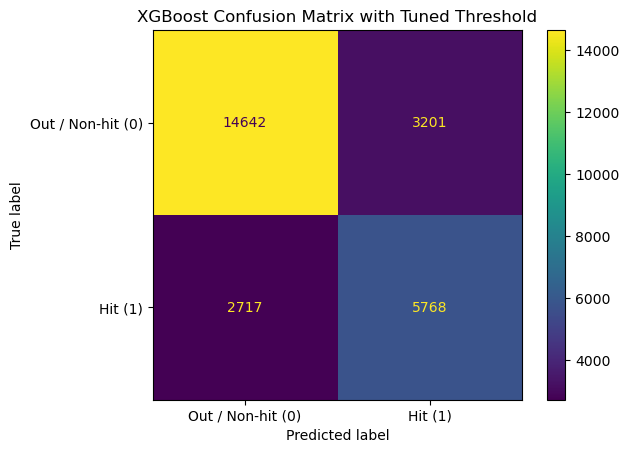

In [32]:
# Predicted probability of class 1 = hit
y_test_proba = xgb_binary_model.predict_proba(X_test)[:, 1]

# Prediction using tuned threshold
y_test_pred_threshold = (y_test_proba >= best_threshold).astype(int)

# Accuracy using tuned threshold
tuned_accuracy = accuracy_score(y_test, y_test_pred_threshold)

# ROC-AUC uses probability, not thresholded labels
final_auc = roc_auc_score(y_test, y_test_proba)

print("========================================")
print("XGBoost with Tuned Threshold")
print("========================================")
print(f"Best threshold: {best_threshold:.2f}")
print(f"Tuned Test Accuracy: {tuned_accuracy:.4f}")
print(f"ROC-AUC:             {final_auc:.4f}")

print("\n[Classification Report]")
print(classification_report(
    y_test,
    y_test_pred_threshold,
    target_names=['Out / Non-hit (0)', 'Hit (1)']
))

cm = confusion_matrix(y_test, y_test_pred_threshold)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Out / Non-hit (0)', 'Hit (1)']
)

disp.plot(values_format='d')
plt.title("XGBoost Confusion Matrix with Tuned Threshold")
plt.show()

### Inspect top Grid Search results


In [34]:
# Show the top parameter combinations ranked by validation ROC-AUC during CV
cv_results = pd.DataFrame(grid_search.cv_results_)

cols = [
    'mean_test_score',
    'std_test_score',
    'mean_train_score',
    'param_n_estimators',
    'param_learning_rate',
    'param_max_depth',
    'param_min_child_weight',
    'param_reg_lambda',
    'param_scale_pos_weight'
]

top_results = cv_results[cols].sort_values(
    by='mean_test_score',
    ascending=False
).head(10)

print("Top 10 Grid Search results by CV ROC-AUC:")
display(top_results)

Top 10 Grid Search results by CV ROC-AUC:


,mean_test_score,std_test_score,mean_train_score,param_n_estimators,param_learning_rate,param_max_depth,param_min_child_weight,param_reg_lambda,param_scale_pos_weight
12,0.828620,0.002795,0.830139,600,0.03,2,20,1.0,1.0
14,0.828617,0.002759,0.830117,600,0.03,2,20,5.0,1.0
6,0.828612,0.002760,0.830119,600,0.03,2,10,5.0,1.0
4,0.828610,0.002790,0.830143,600,0.03,2,10,1.0,1.0
62,0.828590,0.002820,0.830490,600,0.05,2,20,5.0,1.0
15,0.828588,0.002711,0.830083,600,0.03,2,20,5.0,2.102677
7,0.828586,0.002714,0.830078,600,0.03,2,10,5.0,2.102677
54,0.828576,0.002827,0.830500,600,0.05,2,10,5.0,1.0
60,0.828564,0.002808,0.830511,600,0.05,2,20,1.0,1.0
13,0.828560,0.002714,0.830091,600,0.03,2,20,1.0,2.102677


In [36]:
import pandas as pd

# 1. 確保你使用的是二元分類模型 (0=出局, 1=安打)
# 取得預測機率 (xBA)
xBA_array = xgb_binary_model.predict_proba(X_test)[:, 1]

# 2. 建立一個新的 DataFrame 來進行數據分析
# 把 X_test 複製過來，避免改到原始資料
df_analysis = X_test.copy()

# 加入真實結果與我們算出來的 xBA
df_analysis['Actual_Result'] = y_test
df_analysis['xBA'] = xBA_array

# 3. 算出「運氣值 (Luck Factor)」
# 公式：真實結果 (1或0) - 預期安打率 (xBA)
# 如果結果是 1 (安打)，但 xBA 只有 0.10 -> 運氣值 = +0.90 (超幸運鳥安)
# 如果結果是 0 (出局)，但 xBA 高達 0.95 -> 運氣值 = -0.95 (超衰平飛被接殺)
df_analysis['Luck_Factor'] = df_analysis['Actual_Result'] - df_analysis['xBA']

print("xBA 分析表建置完成！")
print(df_analysis.head())

xBA 分析表建置完成！
      launch_speed  launch_angle  Actual_Result       xBA  Luck_Factor
631           51.5           -69              0  0.207458    -0.207458
4355          73.1           -47              0  0.195677    -0.195677
1419          89.2           -41              0  0.094235    -0.094235
476           91.0            37              0  0.118812    -0.118812
2351          71.8            68              0  0.010575    -0.010575


In [38]:
# 條件：真實結果是出局(0)，但 xBA 大於 0.90
unlucky_hits = df_analysis[(df_analysis['Actual_Result'] == 0) & (df_analysis['xBA'] > 0.90)]
# 依照運氣值由小到大排序 (越負越衰)
print("🏆 本賽季最衰的 5 次擊球：")
print(unlucky_hits.sort_values(by='Luck_Factor').head(5))

🏆 本賽季最衰的 5 次擊球：
      launch_speed  launch_angle  Actual_Result       xBA  Luck_Factor
4096         115.0            14              0  0.923263    -0.923263
1251         110.4            12              0  0.918464    -0.918464
3868         110.7            13              0  0.918464    -0.918464
181          111.7            12              0  0.917473    -0.917473
216          112.4            13              0  0.917473    -0.917473


# 三分類

In [9]:
def categorize_hit(event):
    if event == 'single':
        return 1  # 短程安打
    elif event in ['double', 'triple', 'home_run']:
        return 2  # 長打
    else:
        return 0  # 出局 / 非安打

df_multi = df_in_play[['launch_speed', 'launch_angle', 'events']].copy()
df_multi['hit_class'] = df_multi['events'].apply(categorize_hit)

df_multi = df_multi[
    ['launch_speed', 'launch_angle', 'hit_class']
].dropna()

X_multi = df_multi[['launch_speed', 'launch_angle']]
y_multi = df_multi['hit_class']

print("Class distribution:")
print(y_multi.value_counts().sort_index())

Class distribution:
hit_class
0    89222
1    27574
2    14852
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight


X_train_full_multi, X_test_multi, y_train_full_multi, y_test_multi = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_multi
)

X_train_multi, X_val_multi, y_train_multi, y_val_multi = train_test_split(
    X_train_full_multi,
    y_train_full_multi,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full_multi
)

print("\nTrain classes:", sorted(y_train_multi.unique()))
print("Validation classes:", sorted(y_val_multi.unique()))
print("Test classes:", sorted(y_test_multi.unique()))

# =========================================================
# 3. Sample weights for class imbalance
# =========================================================
sample_weight_train_multi = compute_sample_weight(
    class_weight='balanced',
    y=y_train_multi
)


Train classes: [0, 1, 2]
Validation classes: [0, 1, 2]
Test classes: [0, 1, 2]


In [19]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# !nvidia-smi

# =========================
# 2. Base multiclass XGBoost model
# =========================
base_xgb_multi = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist',
    # device="cuda",
    random_state=42,
    n_jobs=1
)

# =========================
# 3. Grid search parameter space
# =========================
param_grid_multi = {
    'n_estimators': [100, 300, 600],
    'learning_rate': [0.03, 0.05],
    'max_depth': [2, 3, 4, 6, 8, 10, 12],
    'min_child_weight': [2, 10, 20],
    'subsample': [0.85],
    'colsample_bytree': [0.85],
    'reg_lambda': [1.0, 5.0],
    'reg_alpha': [0.0]
}

cv_multi = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# =========================
# 4. GridSearchCV for multiclass ROC-AUC
# =========================
grid_search_multi = GridSearchCV(
    estimator=base_xgb_multi,
    param_grid=param_grid_multi,
    scoring='roc_auc_ovr',
    cv=cv_multi,
    n_jobs=-1,
    verbose=2,
    refit=True,
    return_train_score=True
)

grid_search_multi.fit(
    X_train_multi,
    y_train_multi,
    sample_weight=sample_weight_train_multi
)

print("========================================")
print("Best XGBoost Multiclass Grid Search Result")
print("========================================")
print(f"Best CV ROC-AUC OVR: {grid_search_multi.best_score_:.4f}")
print("Best parameters:")
print(grid_search_multi.best_params_)

# Keep the same variable name as your original code
xgb_multi_model = grid_search_multi.best_estimator_

Fitting 5 folds for each of 252 candidates, totalling 1260 fits
Best XGBoost Multiclass Grid Search Result
Best CV ROC-AUC OVR: 0.8378
Best parameters:
{'colsample_bytree': 0.85, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 300, 'reg_alpha': 0.0, 'reg_lambda': 5.0, 'subsample': 0.85}


Tuned XGBoost Three-Class Classification Result
Test Multiclass ROC-AUC OVR: 0.8375

[Classification Report]
              precision    recall  f1-score   support

      出局 (0)       0.88      0.63      0.74     17845
    短程安打 (1)       0.46      0.70      0.56      5515
      長打 (2)       0.41      0.73      0.53      2970

    accuracy                           0.66     26330
   macro avg       0.59      0.69      0.61     26330
weighted avg       0.74      0.66      0.67     26330



D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23616 (\N{CJK UNIFIED IDEOGRAPH-5C40}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 30701 (\N{CJK UNIFIED IDEOGRAPH-77ED}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23433 (\N{CJK UNIFIED IDEOGRAPH-5B89}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\Lib\site-packages\IPython\core\pylabt

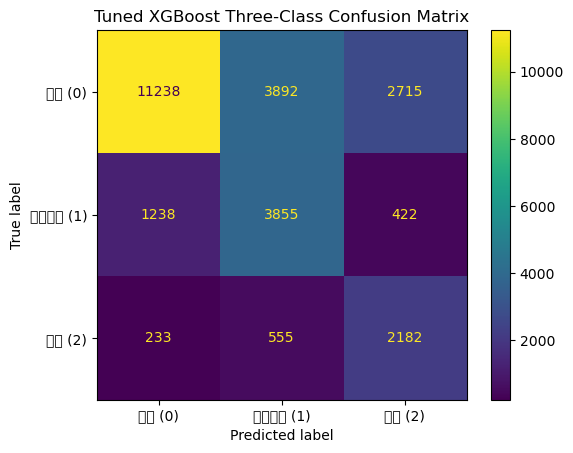

In [35]:
y_test_pred_multi = xgb_multi_model.predict(X_test_multi)
y_test_proba_multi = xgb_multi_model.predict_proba(X_test_multi)

auc_multi = roc_auc_score(
    y_test_multi,
    y_test_proba_multi,
    multi_class='ovr',
    labels=[0, 1, 2]
)

print("========================================")
print("Tuned XGBoost Three-Class Classification Result")
print("========================================")
print(f"Test Multiclass ROC-AUC OVR: {auc_multi:.4f}")

target_names_multi = [
    '出局 (0)',
    '短程安打 (1)',
    '長打 (2)'
]
print("\n[Classification Report]")
print(classification_report(
    y_test_multi,
    y_test_pred_multi,
    labels=[0, 1, 2],
    target_names=target_names_multi
))

cm_multi = confusion_matrix(
    y_test_multi,
    y_test_pred_multi,
    labels=[0, 1, 2]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_multi,
    display_labels=target_names_multi
)

disp.plot(values_format='d')
plt.title("Tuned XGBoost Three-Class Confusion Matrix")
plt.show()